# Nama : Muhammad Iqbal Saputra
# Kelas : 6D
# NIM : 23090120
# Tugas : Big Data Pertemuan2

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2

/content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2


# Scraping beautifulsoup4

In [ ]:
pip install beautifulsoup4 request

ERROR: Could not find a version that satisfies the requirement request (from versions: none)
ERROR: No matching distribution found for request


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL website berita Indonesia (contoh Kompas)
url = "https://www.kompas.com/"

# Mengirim permintaan HTTP ke website
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

# Mengecek apakah request berhasil
if response.status_code == 200:
    # Parsing HTML dengan BeautifulSoup
    soup = BeautifulSoup(response.text, "html.parser")

    # Menemukan semua berita (disesuaikan dengan struktur HTML Kompas)
    articles = soup.find_all("h3", class_="article__title")

    data = []
    for article in articles:
        title = article.get_text(strip=True)  # Judul berita
        link = article.find("a")["href"]  # Link berita
        data.append([title, link])
        print(f"Judul: {title}")
        print(f"Link: {link}\n")

    # Simpan ke DataFrame Pandas
    df = pd.DataFrame(data, columns=["Judul", "Link"])

    # Simpan ke CSV
    df.to_csv("berita_kompas.csv", index=False, encoding="utf-8")

    print("Scraping selesai! Data disimpan dalam 'berita_kompas.csv'.")
else:
    print("Gagal mengambil data. Cek kembali URL atau koneksi internet.")


Judul: Fenomena Joki Antran, Bisnis Baru di Balik Makanan Viral
Link: https://video.kompas.com/watch/1923344/fenomena-joki-antran-bisnis-baru-di-balik-makanan-viral?source=KOMPASCOM&position=wp_terkini__player_1

Judul: Dapat Ucapan Paskah Ortodoks, Putin Sanjung Prabowo di Istana Kremlin
Link: https://www.kgnow.com/watch/1923314/dapat-ucapan-paskah-ortodoks-putin-sanjung-prabowo-di-istana-kremlin?source=KOMPASCOM&position=wp_terkini__player_2

Judul: Membaca Kualitas Perekonomian. Apa Benar Kita Tumbuh? | Naratama Short
Link: https://www.kgnow.com/watch/1923313/membaca-kualitas-perekonomian-apa-benar-kita-tumbuh-naratama-short?source=KOMPASCOM&position=wp_terkini__player_2

Scraping selesai! Data disimpan dalam 'berita_kompas.csv'.


#  Scraping selenium

In [ ]:
# 1. INSTALL CHROME STABLE & CHROMEDRIVER
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add - > /dev/null 2>&1
!echo "deb http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google.list
!apt-get update -qq
!apt-get install -qq -y google-chrome-stable

# Install chromedriver auto-installer
!pip install selenium chromedriver-autoinstaller -q

W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Target Packages (main/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/google.list:1 and /etc/apt/sources.list.d/google.list:2
W: Target Packages (main/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/google.list:1 and /etc/apt/sources.list.d/google.list:2
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Target Packages (main/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/google.list:1 and /etc/apt/sources.list.d/google.list:2
W: Target Packages (main/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/google.list:1 and /etc/apt/sources.list.d/g

In [ ]:
# Setup Chrome
import chromedriver_autoinstaller
chromedriver_autoinstaller.install()

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import os
from datetime import datetime
from google.colab import drive


In [ ]:
def get_driver():
    options = Options()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')
    options.add_argument('--window-size=1920,1080')
    options.add_argument('--user-agent=Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36')
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    return webdriver.Chrome(options=options)

def scrape_detik_selenium_drive():
    print("🚀 Mulai scraping dengan Selenium...")
    driver = get_driver()

    try:
        driver.get("https://www.detik.com/terpopuler")
        wait = WebDriverWait(driver, 15)
        wait.until(EC.presence_of_all_elements_located((By.TAG_NAME, "article")))

        # Scroll
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        import time
        time.sleep(2)

        articles = driver.find_elements(By.TAG_NAME, "article")
        data = []

        for i, art in enumerate(articles[:20], 1):
            try:
                title_elem = art.find_element(By.CSS_SELECTOR, "h3 a, h2 a, .media__title a")
                title = title_elem.text
                link = title_elem.get_attribute("href")

                try:
                    cat = art.find_element(By.CSS_SELECTOR, ".media__label").text
                except:
                    cat = "-"

                data.append({
                    'No': i,
                    'Judul': title,
                    'Kategori': cat,
                    'Link': link,
                    'Scraped_At': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                })
            except:
                continue

        return pd.DataFrame(data)

    finally:
        driver.quit()

df = scrape_detik_selenium_drive()

if not df.empty:
    # Setup path di Drive
    folder_path = '/content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2'
    os.makedirs(folder_path, exist_ok=True)

    # Simpan
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = f"{folder_path}/berita_detik_selenium.csv"

    df.to_csv(file_path, index=False, encoding='utf-8-sig')
    print(f"\n✅ {len(df)} artikel tersimpan di: {file_path}")
    display(df.head())

🚀 Mulai scraping dengan Selenium...

✅ 20 artikel tersimpan di: /content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2/berita_detik_selenium.csv


,No,Judul,Kategori,Link,Scraped_At
0,1,"Sjafrie Temui Menteri Perang AS, Sepakat Tingk...",-,https://news.detik.com/internasional/d-8442916...,2026-04-13 19:04:50
1,2,Trump Ancam Hancurkan Kapal-kapal Iran yang De...,-,https://news.detik.com/internasional/d-8442899...,2026-04-13 19:04:50
2,3,Klasemen Piala AFF U-17 2026: Indonesia di Pun...,-,https://sport.detik.com/sepakbola/liga-indones...,2026-04-13 19:04:51
3,4,Viral SK Anggota Satpol PP Bogor Digadai Atasa...,-,https://news.detik.com/berita/d-8442907/viral-...,2026-04-13 19:04:51
4,5,Rooney: Arsenal Perlu Main 'Kotor' Lawan Man City,-,https://sport.detik.com/sepakbola/liga-inggris...,2026-04-13 19:04:51


#Using API - Wikipedia

In [ ]:
# INSTALL & IMPORT
!pip install wordcloud matplotlib pandas requests -q


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import os
from datetime import datetime
import time


In [ ]:
# FUNGSI FETCH DATA (HEADERS LENGKAP - ANTI 403)
def get_wikipedia_data(keyword):
    url = "https://id.wikipedia.org/w/api.php"

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'application/json, text/javascript, */*; q=0.01',
        'Accept-Language': 'en-US,en;q=0.9,id;q=0.8',
        'Referer': 'https://id.wikipedia.org/'
    }

    params = {
        "action": "query",
        "format": "json",
        "prop": "extracts",
        "titles": keyword,
        "exintro": True,
        "explaintext": True,
        "redirects": 1
    }

    try:
        response = requests.get(url, params=params, headers=headers, timeout=10)
        response.raise_for_status()

        data = response.json()
        pages = data["query"]["pages"]

        for page_id, page in pages.items():
            if page_id != "-1" and "extract" in page:
                return {
                    "Keyword": keyword,
                    "Title": page["title"],
                    "Summary": page["extract"],
                    "Page_ID": page_id,
                    "Length": len(page["extract"]),
                    "Fetched_At": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                }
        return None

    except Exception as e:
        print(f"❌ Error '{keyword}': {str(e)}")
        return None


In [ ]:
# 4. AMBIL DATA
print("🚀 Mengambil data dari Wikipedia Indonesia...\n")

keywords = [
    "Teknologi",
    "Informatika",
    "Sistem Informasi",
    "Data Science",
    "Machine Learning",
    "Kecerdasan Buatan",
    "Big Data",
    "Internet of Things"
]

wiki_data = []

for keyword in keywords:
    print(f"🔍 Mencari: {keyword}")
    data = get_wikipedia_data(keyword)
    if data:
        wiki_data.append(data)
        print(f"   ✅ {data['Title']} ({data['Length']} karakter)")
    time.sleep(0.8)  # Jeda antar request

print(f"\n📊 Total berhasil: {len(wiki_data)} artikel")


🚀 Mengambil data dari Wikipedia Indonesia...

🔍 Mencari: Teknologi
   ✅ Teknologi (1465 karakter)
🔍 Mencari: Informatika
   ✅ Informatika (1630 karakter)
🔍 Mencari: Sistem Informasi
   ✅ Sistem informasi (3629 karakter)
🔍 Mencari: Data Science
🔍 Mencari: Machine Learning
🔍 Mencari: Kecerdasan Buatan
   ✅ Kecerdasan buatan (2754 karakter)
🔍 Mencari: Big Data
🔍 Mencari: Internet of Things
   ✅ Internet untuk Segala (952 karakter)

📊 Total berhasil: 5 artikel


In [ ]:
# 5. SIMPAN KE GOOGLE DRIVE
if wiki_data:
    df_wiki = pd.DataFrame(wiki_data)

    # Buat folder di Drive jika belum ada
    folder_path = '/content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2'
    os.makedirs(folder_path, exist_ok=True)

    # Generate nama file dengan timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"wikipedia_data.csv"
    file_path = os.path.join(folder_path, filename)

    # Simpan ke Drive
    df_wiki.to_csv(file_path, index=False, encoding="utf-8-sig")

    # Simpan juga versi latest (overwrite)
    latest_path = os.path.join(folder_path, "wikipedia_latest.csv")
    df_wiki.to_csv(latest_path, index=False, encoding="utf-8-sig")

    print(f"\n💾 File tersimpan di Google Drive:")
    print(f"   • {file_path}")
    print(f"   • {latest_path}")

    print(f"\n📋 Preview Data:")
    display(df_wiki[['Title', 'Length', 'Fetched_At']])

else:
    print("❌ Tidak ada data untuk disimpan")



💾 File tersimpan di Google Drive:
   • /content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2/wikipedia_data.csv
   • /content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2/wikipedia_latest.csv

📋 Preview Data:


,Title,Length,Fetched_At
0,Teknologi,1465,2026-04-13 19:05:51
1,Informatika,1630,2026-04-13 19:05:52
2,Sistem informasi,3629,2026-04-13 19:05:53
3,Kecerdasan buatan,2754,2026-04-13 19:05:56
4,Internet untuk Segala,952,2026-04-13 19:05:58



🎨 Membuat WordCloud...


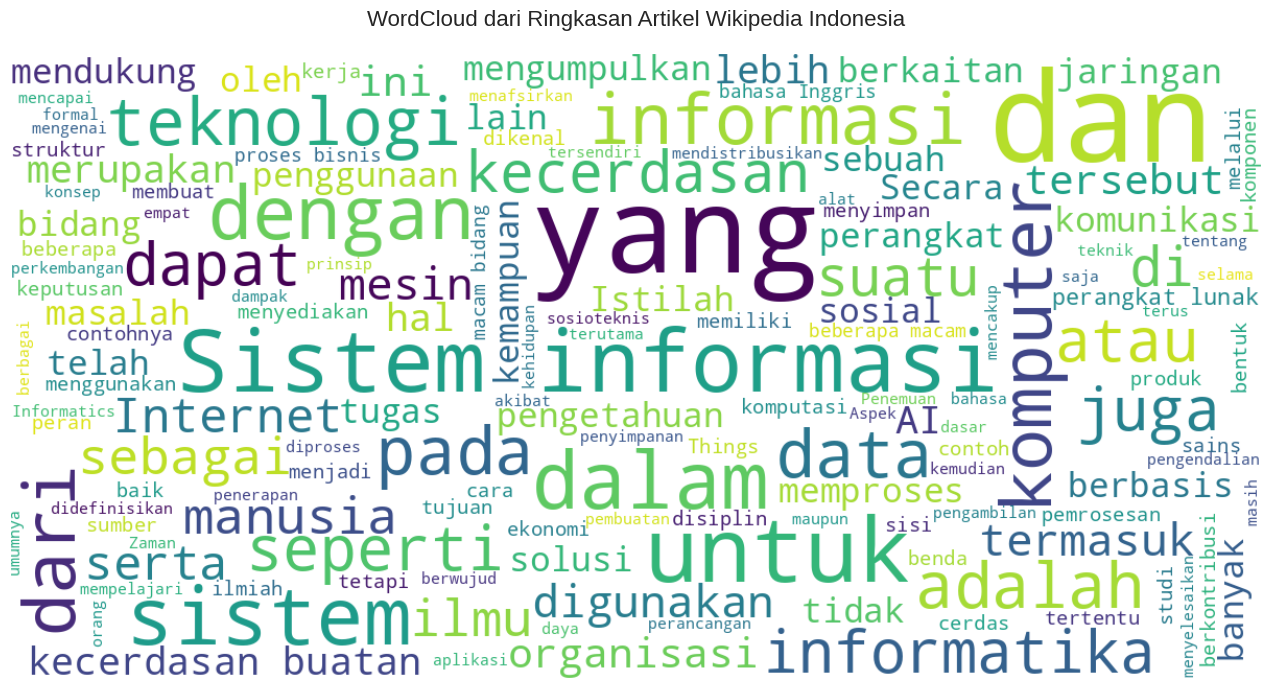

In [ ]:
# 6. VISUALISASI WORDCLOUD
# =========================
if wiki_data:
    print("\n🎨 Membuat WordCloud...")

    # Gabungkan semua summary
    text_data = " ".join(df_wiki["Summary"])

    # Bersihkan teks
    text_clean = re.sub(r'[^\w\s]', ' ', text_data)
    text_clean = re.sub(r'\s+', ' ', text_clean)

    # Buat WordCloud
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        colormap="viridis",
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10,
        max_font_size=120
    ).generate(text_clean)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud dari Ringkasan Artikel Wikipedia Indonesia", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()



📊 Membuat Bar Chart...


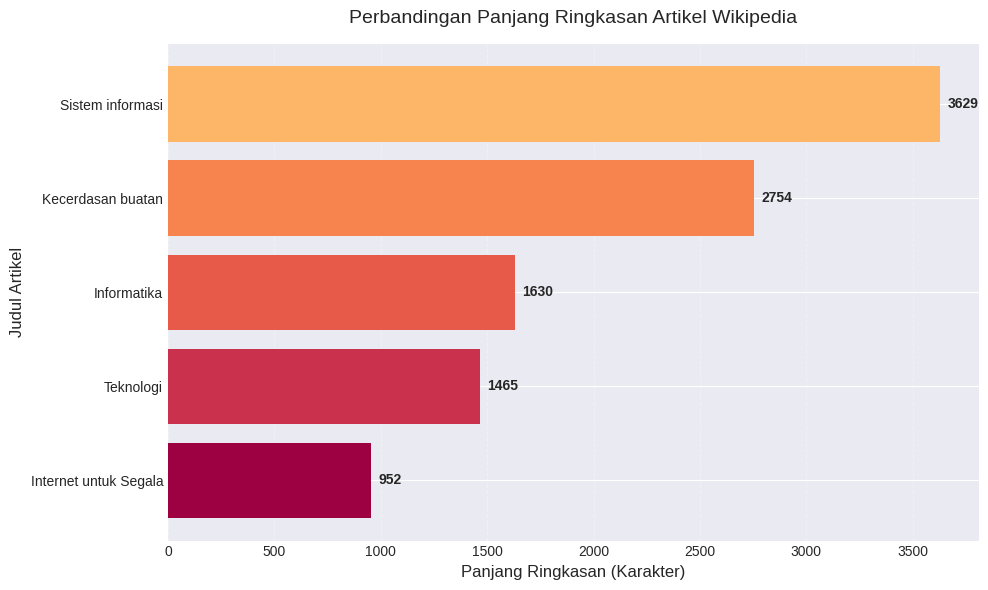


📈 Statistik Data:
   • Total Artikel: 5
   • Rata-rata Panjang: 2086 karakter
   • Median Panjang: 1630 karakter
   • Artikel Terpanjang: Sistem informasi (3629 chars)
   • Artikel Terpendek: Internet untuk Segala (952 chars)

📂 Cek folder di Google Drive: /content/drive/MyDrive/Tugas Kuliah/Big Data/Pertemuan 2


In [ ]:
# VISUALISASI BAR CHART
if wiki_data:
    print("\n📊 Membuat Bar Chart...")

    plt.figure(figsize=(10, 6))

    # Sort untuk visualisasi lebih baik
    df_sorted = df_wiki.sort_values("Length", ascending=True)
    colors = plt.cm.Spectral(range(0, len(df_sorted)*20, 20))

    bars = plt.barh(df_sorted["Title"], df_sorted["Length"], color=colors)

    plt.xlabel("Panjang Ringkasan (Karakter)", fontsize=12)
    plt.ylabel("Judul Artikel", fontsize=12)
    plt.title("Perbandingan Panjang Ringkasan Artikel Wikipedia", fontsize=14, pad=15)
    plt.grid(axis='x', alpha=0.3, linestyle='--')

    # Tambah value label
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + max(df_sorted["Length"])*0.01, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# STATISTIK TAMBAHAN
if wiki_data:
    print("\n📈 Statistik Data:")
    print(f"   • Total Artikel: {len(df_wiki)}")
    print(f"   • Rata-rata Panjang: {df_wiki['Length'].mean():.0f} karakter")
    print(f"   • Median Panjang: {df_wiki['Length'].median():.0f} karakter")
    print(f"   • Artikel Terpanjang: {df_wiki.loc[df_wiki['Length'].idxmax(), 'Title']} ({df_wiki['Length'].max()} chars)")
    print(f"   • Artikel Terpendek: {df_wiki.loc[df_wiki['Length'].idxmin(), 'Title']} ({df_wiki['Length'].min()} chars)")

    print(f"\n📂 Cek folder di Google Drive: /content/drive/MyDrive/Tugas Kuliah/Big Data/Pertemuan 2")

#API BMKG (NIM GENAP = DATA FEBRUARI 2026)

In [ ]:
# SETUP & INSTALLATION
!pip install requests beautifulsoup4 pandas matplotlib seaborn -q

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import os
import time
import re

# Setup style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# SCRAPING DATA (WAYBACK MACHINE)
print("\n🔍 STEP 1: SCRAPING DATA DARI WAYBACK MACHINE...")

wayback_urls = [
    "http://web.archive.org/web/20260215/https://www.bmkg.go.id/gempabumi/gempabumi-dirasakan",
    "http://web.archive.org/web/20260228/https://www.bmkg.go.id/gempabumi/gempabumi-dirasakan",
    "http://web.archive.org/web/20260201/https://www.bmkg.go.id/gempabumi/gempabumi-dirasakan",
]

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
raw_data = []

for url in wayback_urls:
    try:
        print(f"   🌐 Mengakses: {url}")
        response = requests.get(url, headers=headers, timeout=15)

        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            tables = soup.find_all('table')

            for table in tables:
                rows = table.find_all('tr')[1:]  # Skip header
                for row in rows:
                    cols = row.find_all('td')
                    if len(cols) >= 7:
                        # Ambil semua teks dari kolom
                        col_texts = [col.text.strip() for col in cols]

                        # Cari kolom yang mengandung tanggal (format: DD Mmm YYYY)
                        tanggal = ""
                        waktu = ""
                        magnitudo = ""
                        kedalaman = ""
                        lintang = ""
                        bujur = ""
                        wilayah = ""

                        for i, text in enumerate(col_texts):
                            # Deteksi tanggal (contoh: "14 Feb 2026" atau "01 Feb 2026")
                            if re.match(r'\d{1,2}\s+\w+\s+2026', text):
                                tanggal = text
                            # Deteksi waktu (format: HH:MM:SS)
                            elif re.match(r'\d{2}:\d{2}:\d{2}', text):
                                waktu = text
                            # Deteksi magnitudo (angka dengan koma/titik)
                            elif re.match(r'^\d+[,.]\d+$', text) and not magnitudo:
                                magnitudo = text
                            # Deteksi kedalaman (angka diikuti "Km")
                            elif re.match(r'^\d+\s*Km$', text, re.IGNORECASE):
                                kedalaman = text
                            # Deteksi koordinat (mengandung LS/LU dan BT/BB)
                            elif 'LS' in text or 'LU' in text:
                                lintang = text
                            elif 'BT' in text or 'BB' in text:
                                bujur = text
                            # Wilayah (teks panjang mengandung "Pusat gempa")
                            elif 'Pusat gempa' in text or 'pusat gempa' in text:
                                wilayah = text

                        # Filter hanya Februari 2026
                        if 'Feb 2026' in tanggal:
                            raw_data.append({
                                'Tanggal': tanggal,
                                'Waktu': waktu,
                                'Lintang': lintang,
                                'Bujur': bujur,
                                'Magnitudo': magnitudo,
                                'Kedalaman': kedalaman,
                                'Wilayah': wilayah,
                                'Raw_Data': ' | '.join(col_texts),  # Simpan raw untuk debug
                                'Sumber': 'Wayback Machine BMKG'
                            })

            if raw_data:
                print(f"   ✅ Ditemukan {len(raw_data)} data!")
                break
        time.sleep(1)
    except Exception as e:
        print(f"   ⚠️  Error: {str(e)}")
        continue

print(f"\n📊 Total data scraped: {len(raw_data)}")



🔍 STEP 1: SCRAPING DATA DARI WAYBACK MACHINE...
   🌐 Mengakses: http://web.archive.org/web/20260215/https://www.bmkg.go.id/gempabumi/gempabumi-dirasakan
   ✅ Ditemukan 30 data!

📊 Total data scraped: 30


In [ ]:
# DATA PROCESSING
print("\n PROCESSING DATA...")

df = pd.DataFrame(raw_data)

# Bersihkan data dengan error handling
def safe_convert_magnitudo(val):
    """Konversi magnitudo dengan aman"""
    try:
        if pd.isna(val) or val == '':
            return np.nan
        # Hapus karakter non-numerik kecuali koma dan titik
        val_str = str(val).replace(',', '.')
        # Ambil hanya bagian angka
        match = re.search(r'(\d+\.\d+|\d+)', val_str)
        if match:
            return float(match.group(1))
        return np.nan
    except:
        return np.nan

def safe_convert_kedalaman(val):
    """Konversi kedalaman dengan aman"""
    try:
        if pd.isna(val) or val == '':
            return np.nan
        match = re.search(r'(\d+)', str(val))
        if match:
            return float(match.group(1))
        return np.nan
    except:
        return np.nan

# Apply konversi
df['Magnitudo_num'] = df['Magnitudo'].apply(safe_convert_magnitudo)
df['Kedalaman_num'] = df['Kedalaman'].apply(safe_convert_kedalaman)

# Parse Tanggal
df['DateTime'] = pd.to_datetime(df['Tanggal'], format='%d %b %Y', errors='coerce')
df['Tanggal_Parsed'] = df['DateTime'].dt.date
df['Hari'] = df['DateTime'].dt.day

# Extract Koordinat
def extract_coords(lat_str, lon_str):
    try:
        # Extract angka dari string koordinat
        lat_match = re.search(r'(\d+[,.]\d+)', str(lat_str))
        lon_match = re.search(r'(\d+[,.]\d+)', str(lon_str))

        if lat_match and lon_match:
            lat = float(lat_match.group(1).replace(',', '.'))
            lon = float(lon_match.group(1).replace(',', '.'))

            # Cek arah (LS = negatif, LU = positif)
            if 'LS' in str(lat_str) or 'S' in str(lat_str):
                lat = -lat
            if 'BB' in str(lon_str) or 'W' in str(lon_str):
                lon = -lon

            return lat, lon
        return None, None
    except:
        return None, None

coords = df.apply(lambda row: extract_coords(row['Lintang'], row['Bujur']), axis=1)
df['Lat'] = [c[0] for c in coords]
df['Lon'] = [c[1] for c in coords]

# Kategori
df['Kategori'] = pd.cut(df['Magnitudo_num'],
                       bins=[0, 3, 4, 5, 6, 10],
                       labels=['Minor', 'Ringan', 'Sedang', 'Kuat', 'Besar'])

# Hapus data yang tidak valid (magnitudo = NaN)
df_clean = df.dropna(subset=['Magnitudo_num']).copy()

print(f"   ✅ Data valid: {len(df_clean)} records (dari {len(df)} total)")
if len(df_clean) < len(df):
    print(f"   ⚠️  {len(df) - len(df_clean)} records dibuang karena data tidak lengkap")



 PROCESSING DATA...
   ✅ Data valid: 30 records (dari 30 total)


In [ ]:
# SIMPAN DATA CSV
folder = '/content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2'
os.makedirs(folder, exist_ok=True)

csv_path = f'{folder}/gempa_feb2026_complete.csv'
df_clean.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"   💾 Data tersimpan: {csv_path}")


   💾 Data tersimpan: /content/drive/MyDrive/Tugas Kuliah/Big Data_Muhammad Iqbal Saputra/Pertemuan 2/gempa_feb2026_complete.csv



 VISUALIZATION...


/tmp/ipykernel_914/3372836619.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_914/3372836619.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


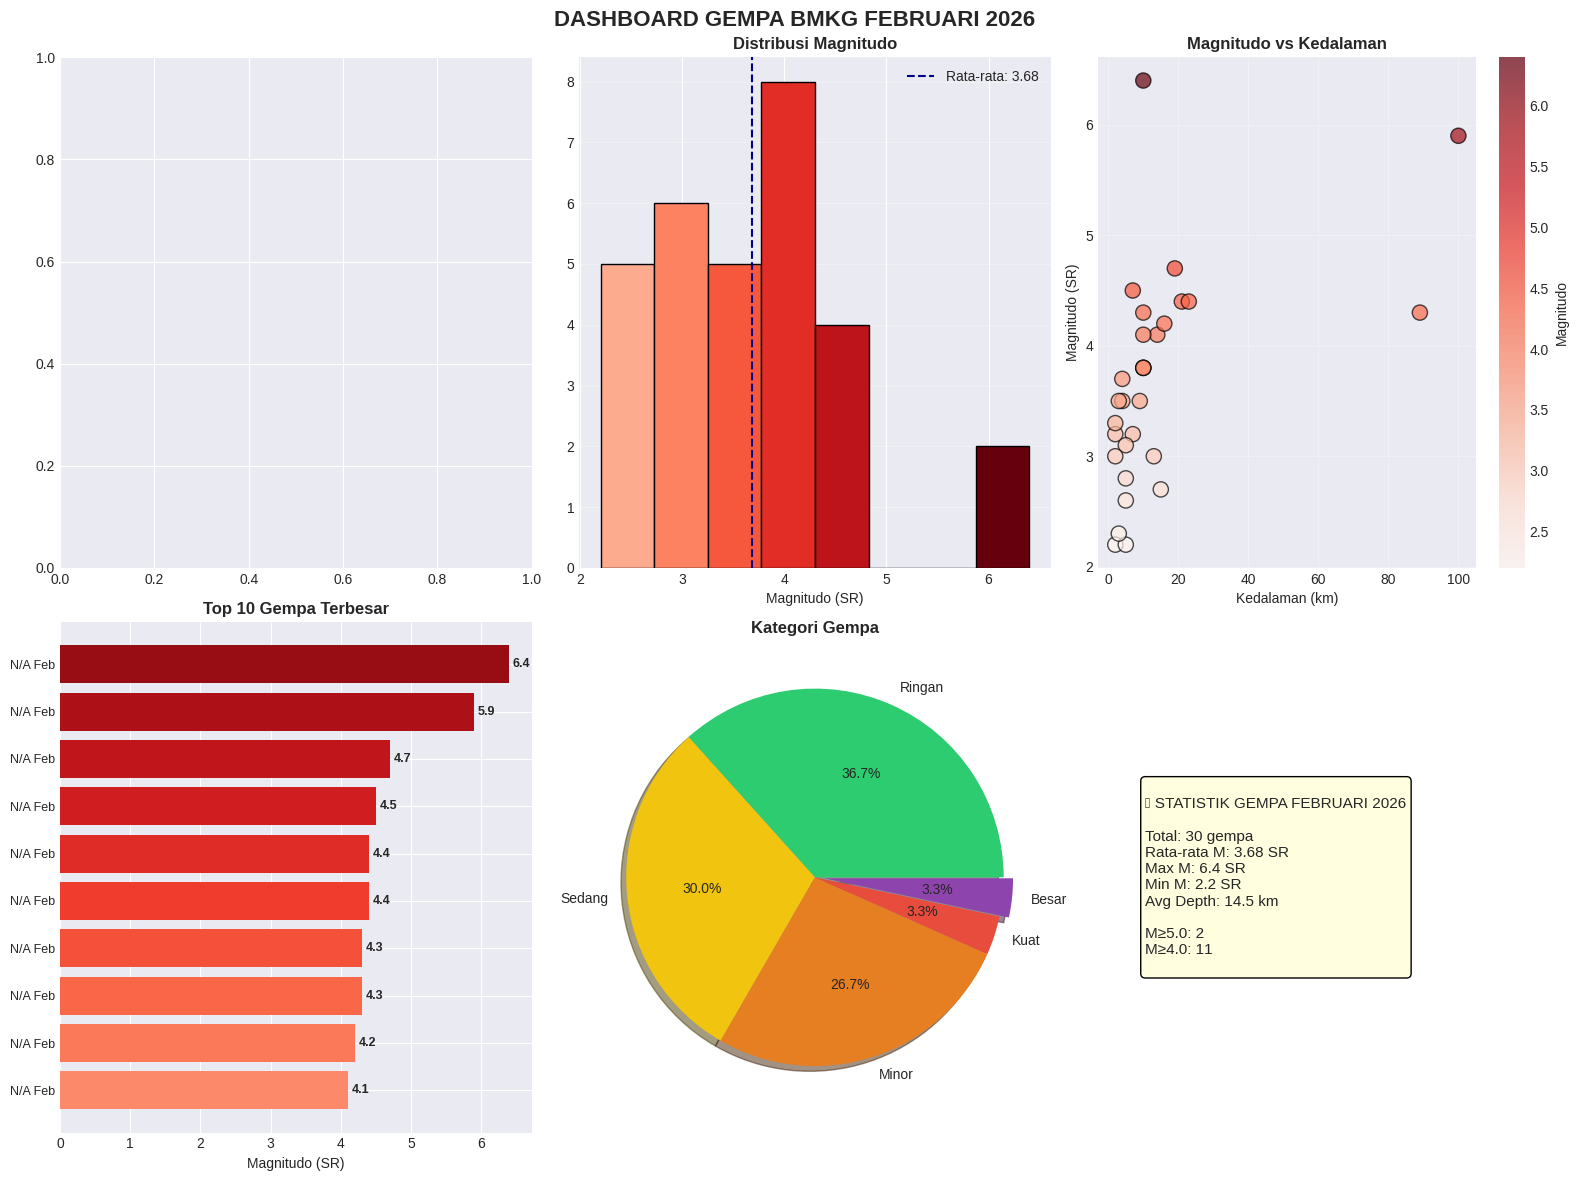

⚠️  Tidak ada data koordinat valid untuk peta


<Figure size 1200x800 with 0 Axes>

In [ ]:

# VISUALIZATION
print("\n VISUALIZATION...")

if len(df_clean) > 0:
    # FIGURE 1: Dashboard Utama
    fig = plt.figure(figsize=(16, 12))

    # 1. Frekuensi per hari
    ax1 = plt.subplot(2, 3, 1)
    if 'Tanggal_Parsed' in df_clean.columns and not df_clean['Tanggal_Parsed'].isna().all():
        daily = df_clean.groupby('Tanggal_Parsed').size()
        colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(daily)))
        daily.plot(kind='bar', color=colors, ax=ax1)
        ax1.set_title('Frekuensi Gempa per Hari', fontweight='bold')
        ax1.set_ylabel('Jumlah')
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(axis='y', alpha=0.3)

    # 2. Distribusi Magnitudo
    ax2 = plt.subplot(2, 3, 2)
    if not df_clean['Magnitudo_num'].isna().all():
        n, bins, patches = ax2.hist(df_clean['Magnitudo_num'], bins=8, color='coral', edgecolor='black')
        for i, patch in enumerate(patches):
            plt.setp(patch, 'facecolor', plt.cm.Reds(0.3 + i/len(patches)))
        ax2.axvline(df_clean['Magnitudo_num'].mean(), color='darkblue', linestyle='--',
                    label=f'Rata-rata: {df_clean["Magnitudo_num"].mean():.2f}')
        ax2.set_title('Distribusi Magnitudo', fontweight='bold')
        ax2.set_xlabel('Magnitudo (SR)')
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)

    # 3. Magnitudo vs Kedalaman
    ax3 = plt.subplot(2, 3, 3)
    valid_data = df_clean.dropna(subset=['Kedalaman_num', 'Magnitudo_num'])
    if len(valid_data) > 0:
        scatter = ax3.scatter(valid_data['Kedalaman_num'], valid_data['Magnitudo_num'],
                             c=valid_data['Magnitudo_num'], cmap='Reds', s=120, alpha=0.7,
                             edgecolors='black')
        plt.colorbar(scatter, ax=ax3, label='Magnitudo')
        ax3.set_title('Magnitudo vs Kedalaman', fontweight='bold')
        ax3.set_xlabel('Kedalaman (km)')
        ax3.set_ylabel('Magnitudo (SR)')
        ax3.grid(True, alpha=0.3)

    # 4. Top 10 Gempa Terbesar
    ax4 = plt.subplot(2, 3, 4)
    top10 = df_clean.nlargest(min(10, len(df_clean)), 'Magnitudo_num').sort_values('Magnitudo_num')
    if len(top10) > 0:
        colors_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(top10)))
        bars = ax4.barh(range(len(top10)), top10['Magnitudo_num'], color=colors_bar)
        ax4.set_yticks(range(len(top10)))
        labels = [f"{'Hari '+str(row['Hari']) if pd.notna(row['Hari']) else 'N/A'} Feb" for _, row in top10.iterrows()]
        ax4.set_yticklabels(labels, fontsize=9)
        ax4.set_xlabel('Magnitudo (SR)')
        ax4.set_title(f'Top {len(top10)} Gempa Terbesar', fontweight='bold')
        for i, (idx, row) in enumerate(top10.iterrows()):
            ax4.text(row['Magnitudo_num'] + 0.05, i, f"{row['Magnitudo_num']:.1f}",
                    va='center', fontsize=9, fontweight='bold')

    # 5. Pie Chart Kategori
    ax5 = plt.subplot(2, 3, 5)
    kategori_counts = df_clean['Kategori'].value_counts()
    if len(kategori_counts) > 0:
        colors_pie = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
        explode = [0.05 if i == len(kategori_counts)-1 else 0 for i in range(len(kategori_counts))]
        ax5.pie(kategori_counts, labels=kategori_counts.index, autopct='%1.1f%%',
                colors=colors_pie[:len(kategori_counts)], explode=explode, shadow=True)
        ax5.set_title('Kategori Gempa', fontweight='bold')

    # 6. Statistik
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    stats = f"""
📊 STATISTIK GEMPA FEBRUARI 2026

Total: {len(df_clean)} gempa
Rata-rata M: {df_clean['Magnitudo_num'].mean():.2f} SR
Max M: {df_clean['Magnitudo_num'].max():.1f} SR
Min M: {df_clean['Magnitudo_num'].min():.1f} SR
Avg Depth: {df_clean['Kedalaman_num'].mean():.1f} km

M≥5.0: {len(df_clean[df_clean['Magnitudo_num'] >= 5])}
M≥4.0: {len(df_clean[df_clean['Magnitudo_num'] >= 4])}
    """
    ax6.text(0.1, 0.5, stats, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black'))

    plt.suptitle('DASHBOARD GEMPA BMKG FEBRUARI 2026', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # FIGURE 2: Peta Sebaran
    plt.figure(figsize=(12, 8))
    valid_coord = df_clean.dropna(subset=['Lat', 'Lon'])
    if len(valid_coord) > 0:
        scatter = plt.scatter(valid_coord['Lon'], valid_coord['Lat'],
                             s=valid_coord['Magnitudo_num']**2 * 10,
                             c=valid_coord['Magnitudo_num'], cmap='Reds',
                             alpha=0.6, edgecolors='black')
        plt.colorbar(scatter, label='Magnitudo (SR)')
        plt.title('PETA SEBARAN GEMPA INDONESIA\nFebruari 2026', fontsize=14, fontweight='bold')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='green', linestyle='--', alpha=0.5)

        for idx, row in valid_coord.iterrows():
            if row['Magnitudo_num'] >= 4.5:
                plt.annotate(f"M{row['Magnitudo_num']}",
                            (row['Lon'], row['Lat']),
                            xytext=(10, 10), textcoords='offset points',
                            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                            fontsize=9, fontweight='bold')
        plt.show()
    else:
        peta_path = "Tidak tersedia (tidak ada data koordinat valid)"
        print("⚠️  Tidak ada data koordinat valid untuk peta")